In [1]:
from cellpose import models
from skimage import io as skio
from skimage.measure import regionprops_table, label
import matplotlib.pyplot as plt
import pandas as pd
from cellpose import models
from skimage.io import imread
from skimage.measure import regionprops_table, label
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
import numpy as np





Welcome to CellposeSAM, cellpose v
cellpose version: 	4.0.5 
platform:       	linux 
python version: 	3.11.7 
torch version:  	2.10.0+cu128! The neural network component of
CPSAM is much larger than in previous versions and CPU excution is slow. 
We encourage users to use GPU/MPS if available. 




In [124]:
# === 1. Charger l'image ===
img_path = "Trachea Hoechst Cazzini_12.tif"  
img_pil = Image.open(img_path).convert("RGB")  # conversion en RGB
img = np.array(img_pil)

In [125]:
print("Shape de l'image :", img.shape)

Shape de l'image : (1440, 1920, 3)


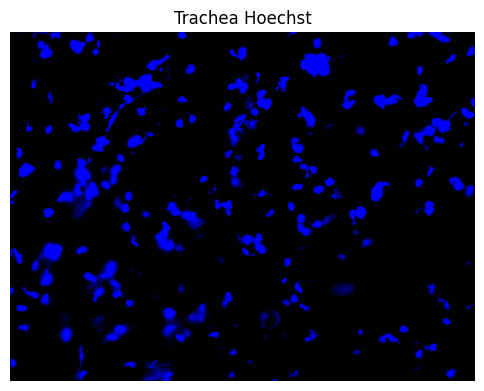

In [126]:
# Afficher l'image
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title("Trachea Hoechst")
plt.axis("off")
plt.show()

In [127]:
# Conversion en niveaux de gris (Hoechst = canal bleu)
img_gray = img[:, :, 2]  # canal bleu (R=0, G=1, B=2)

In [128]:
# 3. Initialiser le modèle
model = models.CellposeModel(gpu=True, model_type='cyto')  # GPU=True si CUDA est dispo


model_type argument is not used in v4.0.1+. Ignoring this argument...


In [129]:
# === 4. Segmenter l'image ===
masks, flows, styles = model.eval(img_gray, diameter=None, resample=False)

In [130]:
# === 5. Extraire les propriétés des cellules segmentées ===
props = regionprops_table(
    label(masks),
    intensity_image=img_gray,
    properties=[
        'label', 'area', 'eccentricity', 'solidity',
        'perimeter', 'major_axis_length', 'minor_axis_length',
        'centroid'
    ]
)

df = pd.DataFrame(props)


In [131]:
# === 6. Afficher le nombre de cellules détectées ===
print("Nombre de cellules détectées :", len(df))

Nombre de cellules détectées : 215


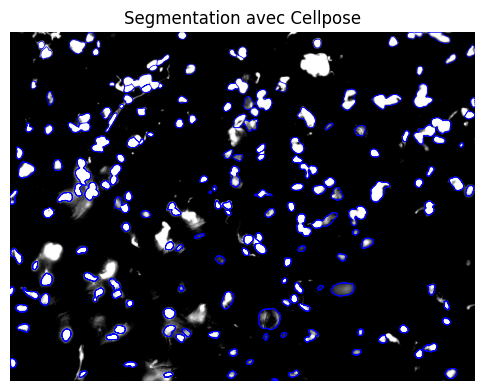

In [132]:
# === 7. Visualiser les masques sur l’image originale ===
plt.figure(figsize=(6, 6))
plt.imshow(img_gray, cmap='gray')
plt.contour(masks, colors='b', linewidths=0.5)
plt.title("Segmentation avec Cellpose")
plt.axis('off')
plt.show()


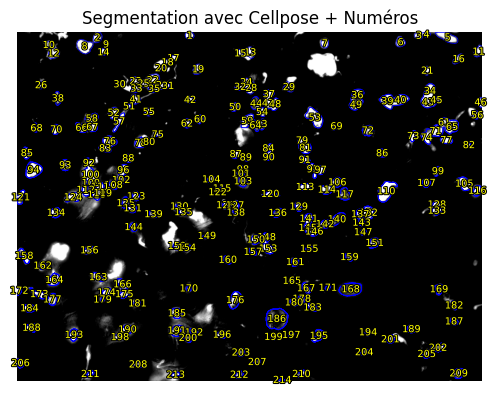

In [133]:
# === 8. Visualiser les masques avec leurs numéros ===
import matplotlib.patheffects as pe
from skimage.measure import regionprops

plt.figure(figsize=(6, 6))
plt.imshow(img_gray, cmap='gray')
plt.contour(masks, colors='b', linewidths=0.5)

# Ajouter les numéros au centroïde de chaque masque
for r in regionprops(masks):
    y, x = r.centroid  # coordonnées (ligne, colonne)
    lab = r.label
    plt.text(
        x, y, str(lab),
        color='yellow', fontsize=7, ha='center', va='center',
        path_effects=[pe.withStroke(linewidth=1.5, foreground="black")]
    )

plt.title("Segmentation avec Cellpose + Numéros")
plt.axis('off')
plt.show()


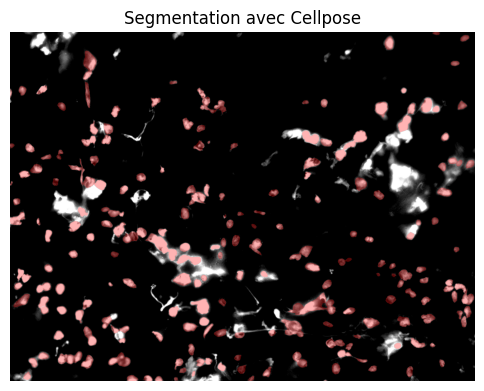

In [17]:
# === 9. Visualiser les masques remplis (en rouge) sur l'image originale ===
plt.figure(figsize=(6, 6))
plt.imshow(img_gray, cmap='gray')

# Créer un overlay rouge transparent
mask_overlay = np.zeros((*masks.shape, 4))  # RGBA
mask_overlay[masks > 0] = [1, 0, 0, 0.3]   # rouge avec alpha=0.3

plt.imshow(mask_overlay)
plt.title("Segmentation avec Cellpose")
plt.axis('off')
plt.show()


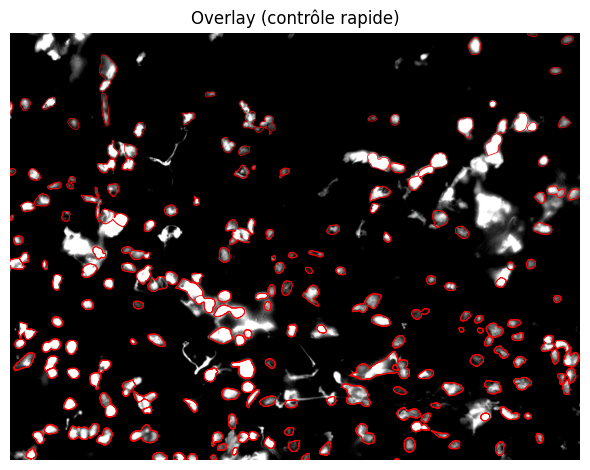

Fichiers sauvegardés :
 - cellpose_out/Trachea Hoechst Cazzini_07_image_for_napari.tif
 - cellpose_out/Trachea Hoechst Cazzini_07_labels_for_napari.tif
 - cellpose_out/Trachea Hoechst Cazzini_07_overlay.png


In [18]:
from pathlib import Path
import tifffile as tiff

# === Paramètres de sortie ===
outdir = Path("./cellpose_out")
outdir.mkdir(parents=True, exist_ok=True)

base = Path(img_path).stem
img_out  = outdir / f"{base}_image_for_napari.tif"
mask_out = outdir / f"{base}_labels_for_napari.tif"
png_over = outdir / f"{base}_overlay.png"

# === 1) Préparer et sauvegarder l'image ===
# Si tu veux garder le 16-bit tel quel, ne change rien.
# Sinon pour alléger, décommente pour convertir en 8-bit :
# img_to_save = (img_gray / img_gray.max() * 255).astype(np.uint8)
img_to_save = img_gray  # garde le dtype original

tiff.imwrite(str(img_out), img_to_save)

# === 2) Sauvegarder le masque en uint16 (format idéal pour "Labels" dans napari) ===
masks_u16 = masks.astype(np.uint16)
tiff.imwrite(str(mask_out), masks_u16)

# === 3) (optionnel) Un overlay PNG pour contrôle visuel rapide ===
plt.figure(figsize=(6, 6))
plt.imshow(img_gray, cmap='gray')
plt.contour(masks, colors='r', linewidths=0.5)
plt.title("Overlay (contrôle rapide)")
plt.axis('off')
plt.tight_layout()
plt.savefig(png_over, dpi=200)
plt.show()

print("Fichiers sauvegardés :")
print(" -", img_out)
print(" -", mask_out)
print(" -", png_over)
